Universidade Federal de Pernambuco <br>
Disciplina: Economia Monetária <br>
Professor: Rafael Vasconcelos <br>
Alunos: João Pedro Miranda, Paulo Silva, Pedro Moraes

Problema 1: Imagine que você é o presidente do Conselho Monetário Nacional (CMN).
Faça uma réplica à carta do Presidente do Banco Central do Brasil. Para isso, relate prós
e contras do descumprimento do regime de metas de inflação para a condução da política
monetária no Brasil. Utilize a teoria econômica e os dados agregados para fundamentar os
seus argumentos.

In [ ]:
# Importações
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import plotly.express as px

# Excluindo eixos do topo e direito dos gráficos
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

In [ ]:
# Importando Bases
DB_CNT = pd.read_excel("/content/Tab_Compl_CNT_3T22.xls")

DB_IeG = pd.read_csv("/content/preços e gastos.csv", sep=";", encoding="latin1")

DB_PIB = pd.read_excel("/content/ipeadata[16-02-2023-05-25].xls")

In [ ]:
# Removendo última linha
DB_IeG=DB_IeG.drop(len(DB_IeG)-1)

In [ ]:
# Obtendo range especifico
DB_IeG=DB_IeG.iloc[456:]

In [ ]:
# Obtendo range especifico
DB_PIB = DB_PIB.iloc[88:]

In [ ]:
# Remover linhas especificas
DB_IeG.drop([516,515,514,513],inplace=True)

In [ ]:
# Impor coluna data como index
DB_IeG.set_index("Data",inplace=True)

In [ ]:
# Ajustar frequência para mensal
DB_IeG.index=pd.DatetimeIndex(DB_IeG.index,freq="MS")

In [ ]:
# Ajustar pontos e virgulas
DB_IeG=DB_IeG.replace(" ", "",regex=True)
DB_IeG=DB_IeG.replace(",", ".",regex=True)

In [ ]:
# Ajustar para float
DB_IeG['433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal']=DB_IeG['433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal'].astype(float)

In [ ]:
# Verificar dados
DB_IeG['433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal']

Data
2018-01-01    0.29
2018-02-01    0.32
2018-03-01    0.09
2018-04-01    0.22
2018-05-01    0.40
2018-06-01    1.26
2018-07-01    0.33
2018-08-01   -0.09
2018-09-01    0.48
2018-10-01    0.45
2018-11-01   -0.21
2018-12-01    0.15
2019-01-01    0.32
2019-02-01    0.43
2019-03-01    0.75
2019-04-01    0.57
2019-05-01    0.13
2019-06-01    0.01
2019-07-01    0.19
2019-08-01    0.11
2019-09-01   -0.04
2019-10-01    0.10
2019-11-01    0.51
2019-12-01    1.15
2020-01-01    0.21
2020-02-01    0.25
2020-03-01    0.07
2020-04-01   -0.31
2020-05-01   -0.38
2020-06-01    0.26
2020-07-01    0.36
2020-08-01    0.24
2020-09-01    0.64
2020-10-01    0.86
2020-11-01    0.89
2020-12-01    1.35
2021-01-01    0.25
2021-02-01    0.86
2021-03-01    0.93
2021-04-01    0.31
2021-05-01    0.83
2021-06-01    0.53
2021-07-01    0.96
2021-08-01    0.87
2021-09-01    1.16
2021-10-01    1.25
2021-11-01    0.95
2021-12-01    0.73
2022-01-01    0.54
2022-02-01    1.01
2022-03-01    1.62
2022-04-01    1.06
2022-05

In [ ]:
# Realizar cálculo do ipca trimestral acumulado
ipcaTrimestral=[]

for i in range(0,len(DB_IeG)-1,3):
  ipcaTrimestral.append(((1+DB_IeG["433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal"][i+1]/100)*(1+DB_IeG["433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal"][i+2]/100)*(1+DB_IeG["433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal"][i]/100)-1)*100)

In [ ]:
ipcaTrimestral

[0.701477835200004,
 1.8887030879999767,
 0.7208535743999933,
 0.3894135824999978,
 1.507011320000018,
 0.7108110741000262,
 0.2600889164000142,
 1.7675308649999888,
 0.5308473674999981,
 -0.4306129372000145,
 1.2447095295999855,
 3.13138232900001,
 2.052492994999988,
 1.6786286369000258,
 3.0196768831999954,
 2.958021687500012,
 3.2006523548000043,
 2.2152663793999716,
 -1.3245430992000151]

In [ ]:
# Realizar agrupamento de mensal para trimestral através de soma
trimestral=DB_IeG.resample("Q").sum()

In [ ]:
# Substituir pela inflação trimestral cálculada manualmente
trimestral["inflacao"]=ipcaTrimestral

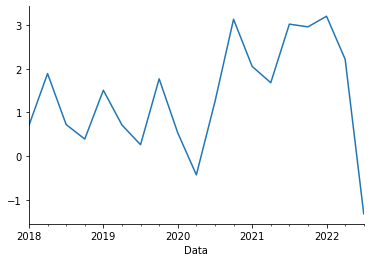

In [ ]:
# Observar com matplotlib
trimestral["inflacao"].plot()

In [ ]:
# Observar com plotly
px.line(trimestral,trimestral.index,"inflacao")

In [ ]:
# Exportar base
trimestral.to_excel("/content/InflaTrimes.xlsx")